In [13]:
# Custom utilities
import importlib
import NO_utilities

# Standard libraries
import gc
import hashlib
import json
import os
import random
import sys
import time
from datetime import datetime
from pathlib import Path

# Scientific computing
import numpy as np
import scipy as sp

# Deep learning - PyTorch
import torch
import torch.fft
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import (
    ConcatDataset,
    DataLoader,
    Dataset,
    TensorDataset,
    random_split,
)

# Neural operator specific
from neuralop import H1Loss, LpLoss, Trainer
from neuralop.models import FNO, FNO2d, TFNO, TFNO2d

# Data processing and visualization
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torchvision import transforms

In [14]:
# Force garbage collection to release file handles
gc.collect()

141875

## Load and visualize data

In [15]:
# Resolve repo root even when notebook cwd is nested.
start_dir = Path.cwd().resolve()
repo_root = None
for candidate in [start_dir, *start_dir.parents]:
    if (candidate / "DATASETS" / "b_test").exists():
        repo_root = candidate
        break
if repo_root is None:
    raise FileNotFoundError(f"Could not locate DATASETS/b_test from cwd={start_dir}")

dataset_root = repo_root / "DATASETS" / "b_test"
pt_candidates = [p for p in dataset_root.iterdir() if p.is_dir() and p.name.endswith("_pt")]
if not pt_candidates:
    raise FileNotFoundError(f"No *_pt folder under {dataset_root}")
reduced_dataset_path = max(pt_candidates, key=lambda p: p.stat().st_mtime)
# Inputs; targets are ch0 = eigenfrequency_uniform_full.pt, ch1–4 = displacements_dataset.pt (TensorDataset)
geometries = torch.load(reduced_dataset_path / "geometries_full.pt", weights_only=False)
waveforms = torch.load(reduced_dataset_path / "waveforms_full.pt", weights_only=False)
band_ffts = torch.load(reduced_dataset_path / "band_fft_full.pt", weights_only=False)
eigenfrequency_uniform = torch.load(reduced_dataset_path / "eigenfrequency_uniform_full.pt", weights_only=False)
# eigenfrequency_fft = torch.load(reduced_dataset_path / "eigenfrequency_fft_full.pt", weights_only=False)
displacements = torch.load(reduced_dataset_path / "displacements_dataset.pt", weights_only=False)
reduced_indices = torch.load(reduced_dataset_path / "reduced_indices.pt", weights_only=False)

n_design = geometries.shape[0]
n_wv = waveforms.shape[0]
n_band = band_ffts.shape[0]
disp_rows = displacements.tensors[0].shape[0]
n_reduced = len(reduced_indices)
full_rows = n_design * n_wv * n_band
if disp_rows == full_rows:
    disp_mode = "full"
elif disp_rows == n_reduced:
    disp_mode = "reduced_aligned"
else:
    raise ValueError(
        f"displacements_dataset row count {disp_rows} neither full ({full_rows}) nor reduced ({n_reduced})"
    )

def stack_target_channels(sample_idx: int, d: int, w: int, b: int) -> torch.Tensor:
    """Stack 5×H×W: ch0 from eigenfrequency_uniform_full[d,w,b]; ch1–4 from displacements."""
    ch0 = eigenfrequency_uniform[d, w, b]
    # ch0 = eigenfrequency_fft[d, w, b]
    flat = d * (n_wv * n_band) + w * n_band + b
    chans = [displacements.tensors[i][flat] for i in range(4)]
    return torch.stack([ch0, *chans], dim=0)

print(f"Dataset PT dir: {reduced_dataset_path}")
print(f"disp_mode: {disp_mode}")
print("Dataset components:")
print(f"Geometries: shape {geometries.shape}, dtype {geometries.dtype}")
print(f"Waveforms: shape {waveforms.shape}, dtype {waveforms.dtype}")
print(f"Band FFTs: shape {band_ffts.shape}, dtype {band_ffts.dtype}")
print(f"Eigenfrequency (uniform) full: shape {eigenfrequency_uniform.shape}, dtype {eigenfrequency_uniform.dtype}")
# print(f"Eigenfrequency (fft) full: shape {eigenfrequency_fft.shape}, dtype {eigenfrequency_fft.dtype}")
print(f"Displacements type: {type(displacements)}")
if hasattr(displacements, "tensors"):
    for i, tensor in enumerate(displacements.tensors):
        print(f"  Displacement tensor {i}: shape {tensor.shape}, dtype {tensor.dtype}")
print()

Dataset PT dir: D:\Research\NO-2D-Metamaterials\DATASETS\b_test\binarized_2026-03-08_16-34-27_pt
disp_mode: full
Dataset components:
Geometries: shape torch.Size([1000, 32, 32]), dtype torch.float16
Waveforms: shape torch.Size([325, 32, 32]), dtype torch.float16
Band FFTs: shape torch.Size([6, 32, 32]), dtype torch.float16
Eigenfrequency (uniform) full: shape torch.Size([1000, 325, 6, 32, 32]), dtype torch.float16
Displacements type: <class 'torch.utils.data.dataset.TensorDataset'>
  Displacement tensor 0: shape torch.Size([1950000, 32, 32]), dtype torch.float16
  Displacement tensor 1: shape torch.Size([1950000, 32, 32]), dtype torch.float16
  Displacement tensor 2: shape torch.Size([1950000, 32, 32]), dtype torch.float16
  Displacement tensor 3: shape torch.Size([1950000, 32, 32]), dtype torch.float16



In [16]:
# Get a random sample from reduced_indices
random_idx = np.random.randint(0, len(reduced_indices))
sample_indices = reduced_indices[random_idx]
print('sample_indices:', sample_indices)

# Extract components from the sample using sample_indices
geometry = geometries[sample_indices[0]]
waveform = waveforms[sample_indices[1]]
band_fft = band_ffts[sample_indices[2]] 
input_tensors = torch.stack([geometry, waveform, band_fft])
d, w, b = int(sample_indices[0]), int(sample_indices[1]), int(sample_indices[2])
output_tensors = stack_target_channels(random_idx, d, w, b)

# Print type and shape of each component
print("Geometry type:", type(geometry))
print("Geometry shape:", geometry.shape)
print("Waveform type:", type(waveform))
print("Waveform shape:", waveform.shape)
print("Band FFT type:", type(band_fft))
print("Band FFT shape:", band_fft.shape)
print("Target (5 ch) type:", type(output_tensors))
print("Target (5 ch) shape:", output_tensors.shape)
print(f"Visualizing random sample {random_idx}")
# NO_utilities.visualize_sample(input_tensors, output_tensors, None)

sample_indices: (661, 80, 4)
Geometry type: <class 'torch.Tensor'>
Geometry shape: torch.Size([32, 32])
Waveform type: <class 'torch.Tensor'>
Waveform shape: torch.Size([32, 32])
Band FFT type: <class 'torch.Tensor'>
Band FFT shape: torch.Size([32, 32])
Target (5 ch) type: <class 'torch.Tensor'>
Target (5 ch) shape: torch.Size([5, 32, 32])
Visualizing random sample 258066


## Model evaluation

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using Device:', device)
print("Using PyTorch version:", torch.__version__)


Using Device: cuda
Using PyTorch version: 2.5.1


In [18]:
load_path = Path(
    # r"D:\Research\NO-2D-Metamaterials\MODELS\training_runs\NO_I3O5_BCF16_L2_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260323_20260323_122907_19312\NO_I3O5_BCF16_L2_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260323_best_fno2d_compat.pth"
    r"D:\Research\NO-2D-Metamaterials\MODELS\training_runs\NO_I3O5_BCF16_L1_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260401\NO_I3O5_BCF16_L1_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260401_best_fno2d_compat.pth"
    # r"D:\Research\NO-2D-Metamaterials\MODELS\training_runs\NO_I3O5_BCF16_L1&L2_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260401\NO_I3O5_BCF16_L1&L2_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260401_E30.pth"
)
run_dir = load_path.parent

with open(run_dir / "resolved_config.json", "r", encoding="utf-8") as f:
    cfg = json.load(f)
params = cfg["params"]

model = FNO2d(
    in_channels=int(params["in_channels"]),
    out_channels=int(params["out_channels"]),
    n_modes_height=int(params["modes_height"]),
    n_modes_width=int(params["modes_width"]),
    hidden_channels=int(params["hidden_channels"]),
    n_layers=int(params["layers"]),
).to(device)

if load_path.is_file():
    try:
        state_dict = torch.load(load_path, map_location=device)
        if isinstance(state_dict, dict):
            state_dict = {k: v for k, v in state_dict.items() if not k.startswith("_")}
        model.load_state_dict(state_dict)
        print(f"Loaded converted unwrapped model from {load_path}")
        # print(
        #     f"Model config: in={params['in_channels']}, out={params['out_channels']}, "
        #     f"modes=({params['modes_height']},{params['modes_width']}), hidden={params['hidden_channels']}, layers={params['layers']}"
        # )
    except Exception as e:
        print(f"Error loading converted model: {e}")
        print("Model will start with random weights")
else:
    print(f"Missing converted checkpoint: {load_path}")

model.eval()


C:\Users\hz283\AppData\Local\Temp\ipykernel_122172\1319338955.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(load_path, map_location=device)


Loaded converted unwrapped model from D:\Research\NO-2D-Metamaterials\MODELS\training_runs\NO_I3O5_BCF16_L1_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260401\NO_I3O5_BCF16_L1_HC128_LR2e-03_WD0e+00_SS1_G9e-01_ch0u_260401_best_fno2d_compat.pth


FNO2d(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): DenseTensor(shape=torch.Size([128, 128, 32, 17]), rank=None)
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(128, 128, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(128, 64, kernel_size=(1,), stride=(1,))
          (1): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(5, 256, kernel_size=(1,), stride=(1,))
      (1): Conv1d(256, 128, kernel_size=(1,), stride=(1,))
    )
  )
  (projection): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(128, 256, kernel_size=(1,), stride=(1,))
      (1): Conv1d(256, 5

Sample 0: Input torch.Size([3, 32, 32]) torch.float16, Target torch.Size([5, 32, 32]) torch.float16
Input max: 1.0000, min: -0.7354
Output max: 0.0545, min: -0.0552
Target max: 0.0526, min: -0.0555
Target scale (max - min): 0.1081
Average absolute error per pixel (output vs target): 0.001090


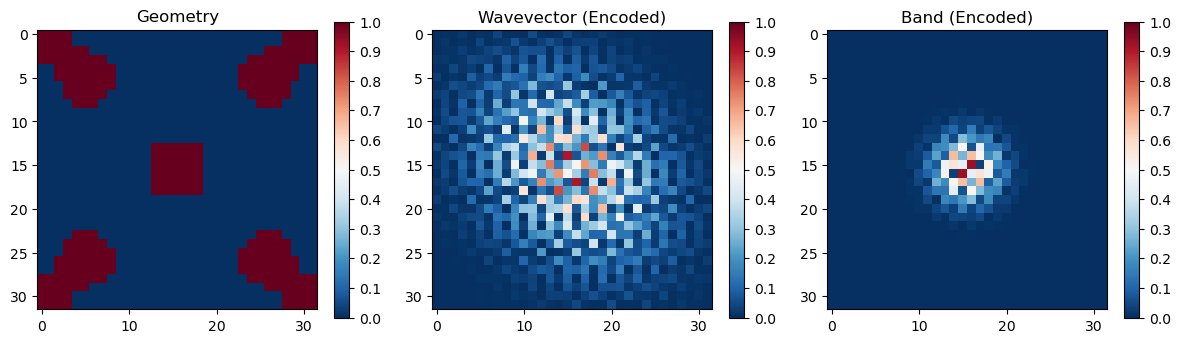

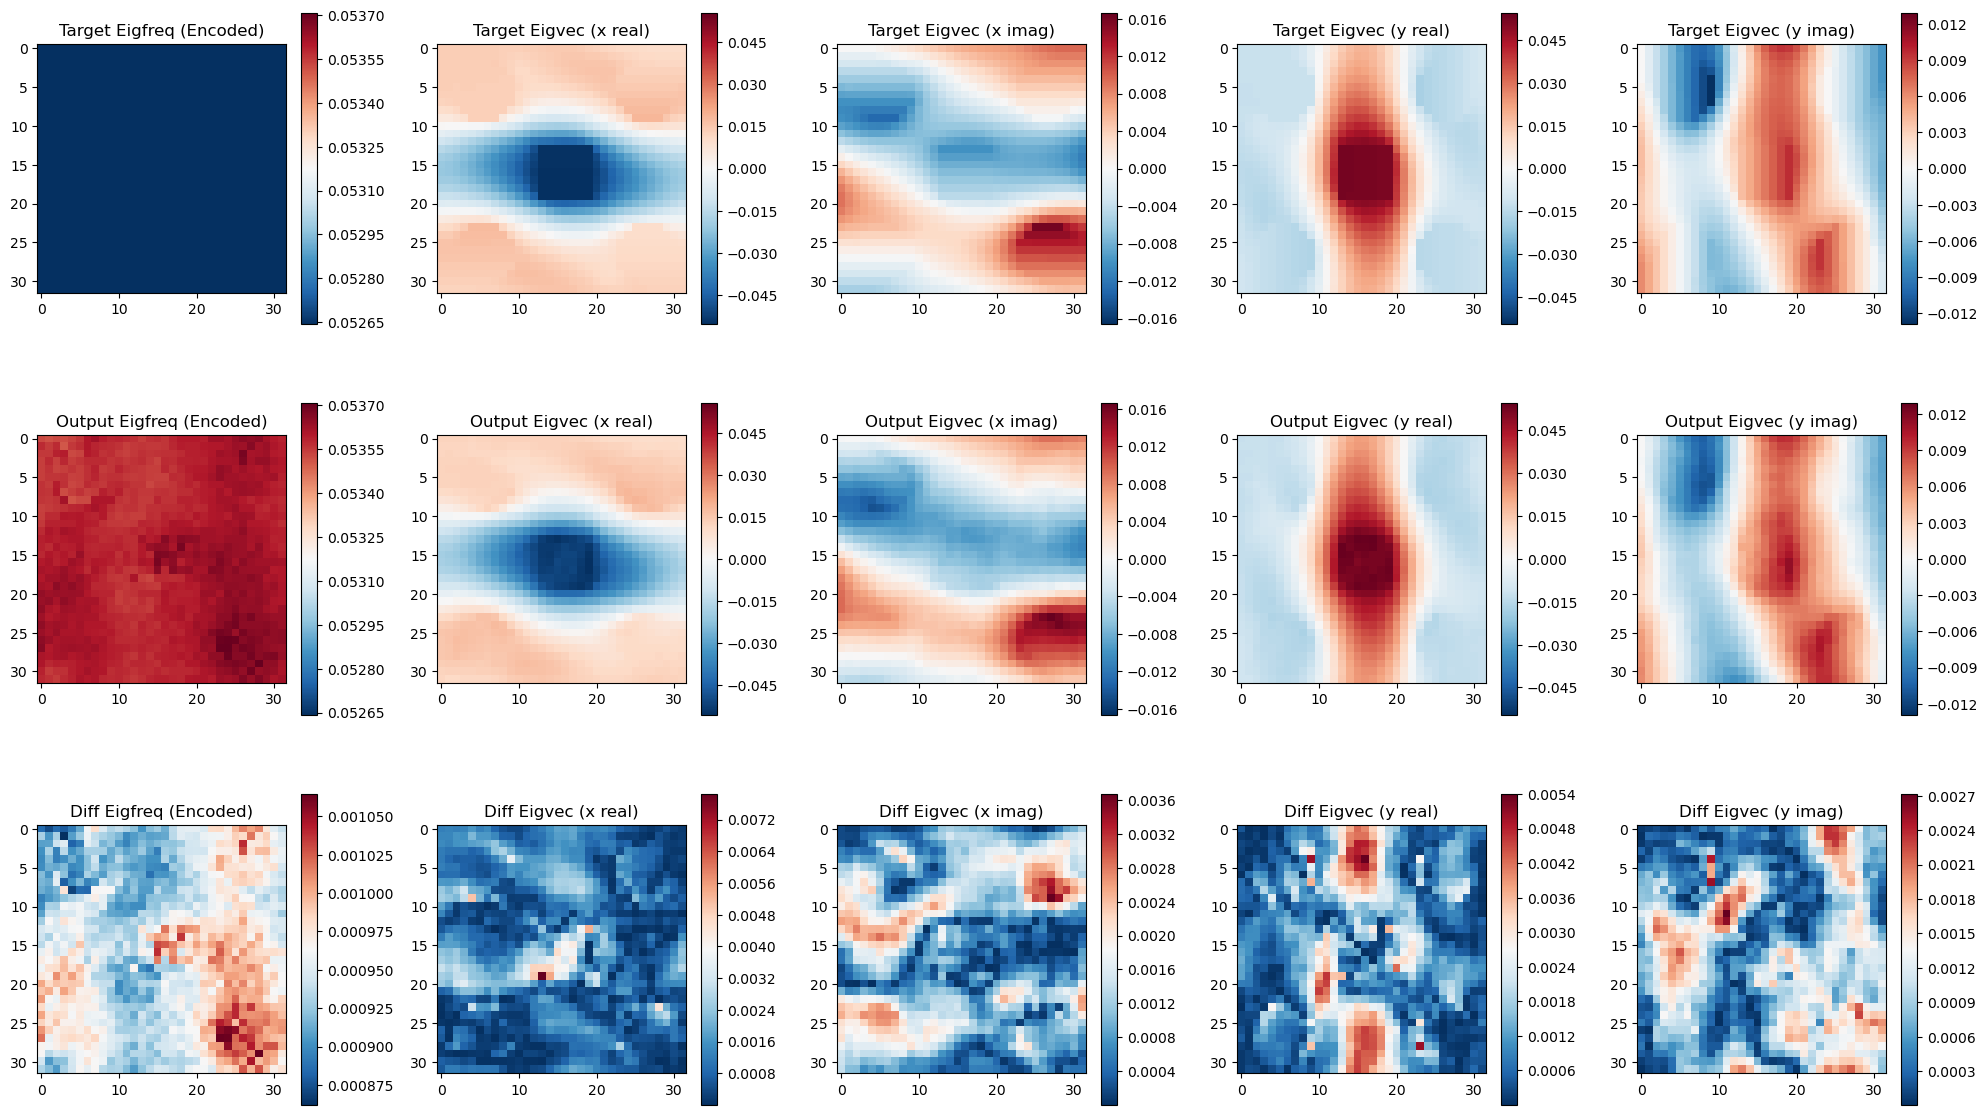

Sample 1: Input torch.Size([3, 32, 32]) torch.float16, Target torch.Size([5, 32, 32]) torch.float16
Input max: 1.0000, min: -0.9697
Output max: 0.1663, min: -0.1626
Target max: 0.1578, min: -0.1516
Target scale (max - min): 0.3094
Average absolute error per pixel (output vs target): 0.000663


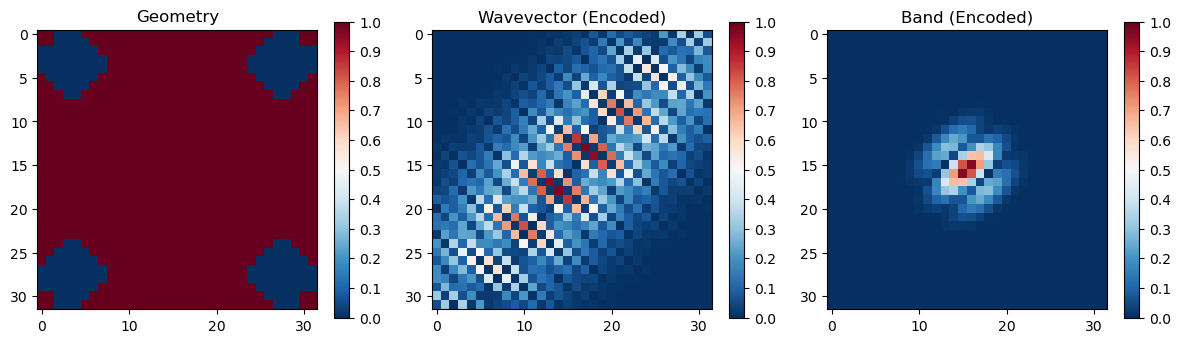

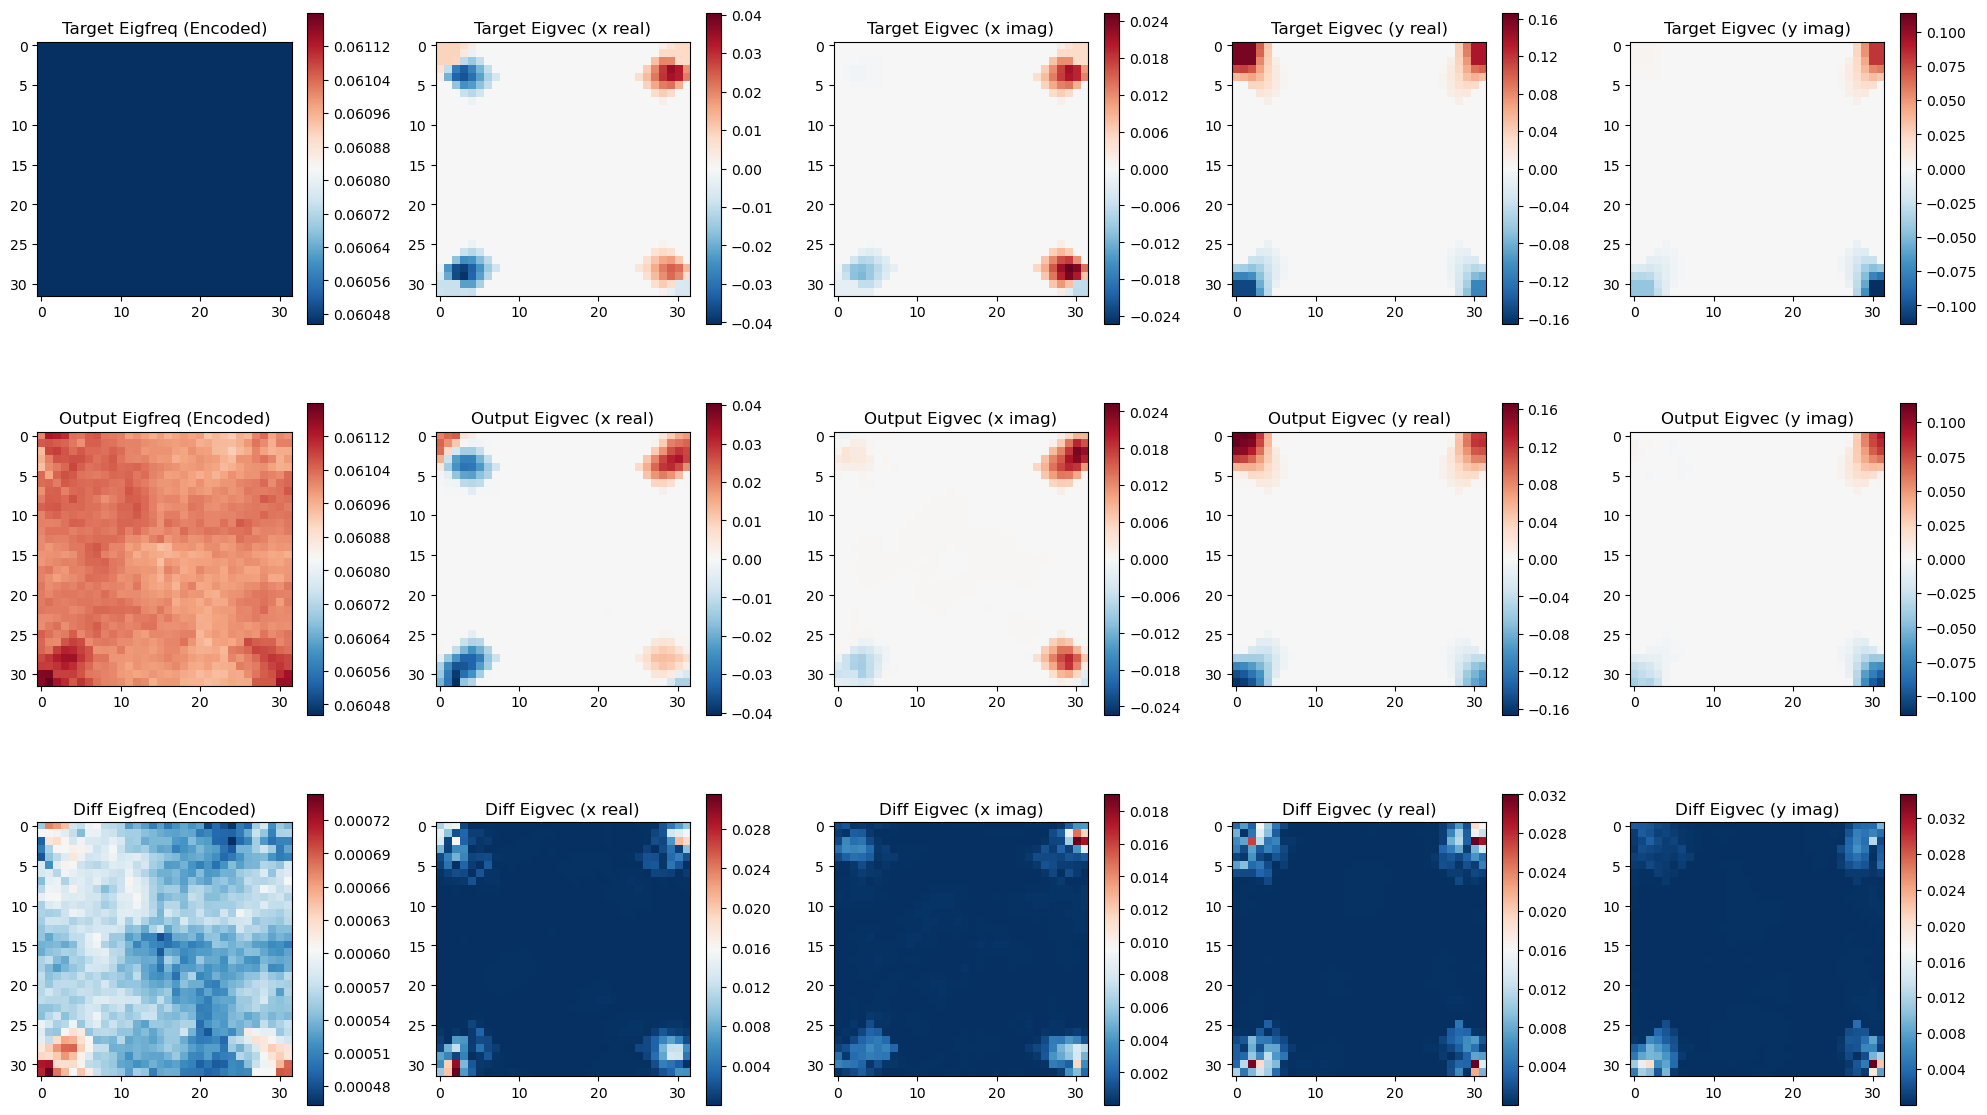

Sample 2: Input torch.Size([3, 32, 32]) torch.float16, Target torch.Size([5, 32, 32]) torch.float16
Input max: 1.0000, min: -0.1282
Output max: 0.0399, min: -0.0274
Target max: 0.0401, min: -0.0267
Target scale (max - min): 0.0668
Average absolute error per pixel (output vs target): 0.000334


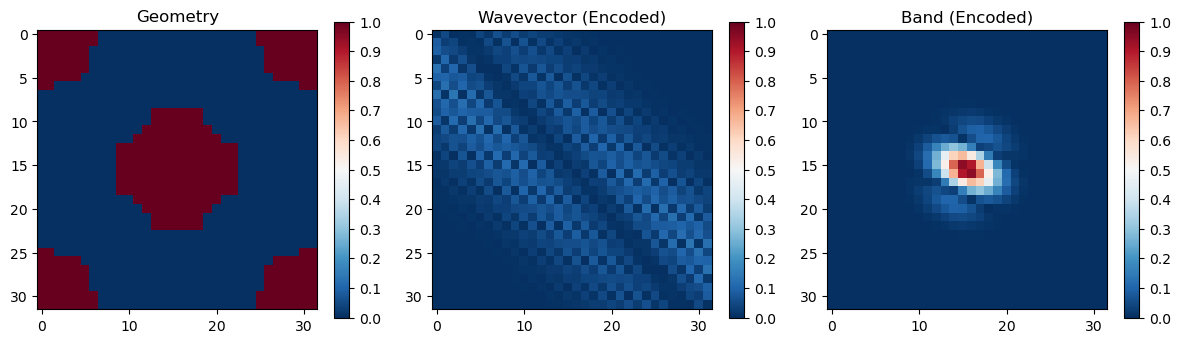

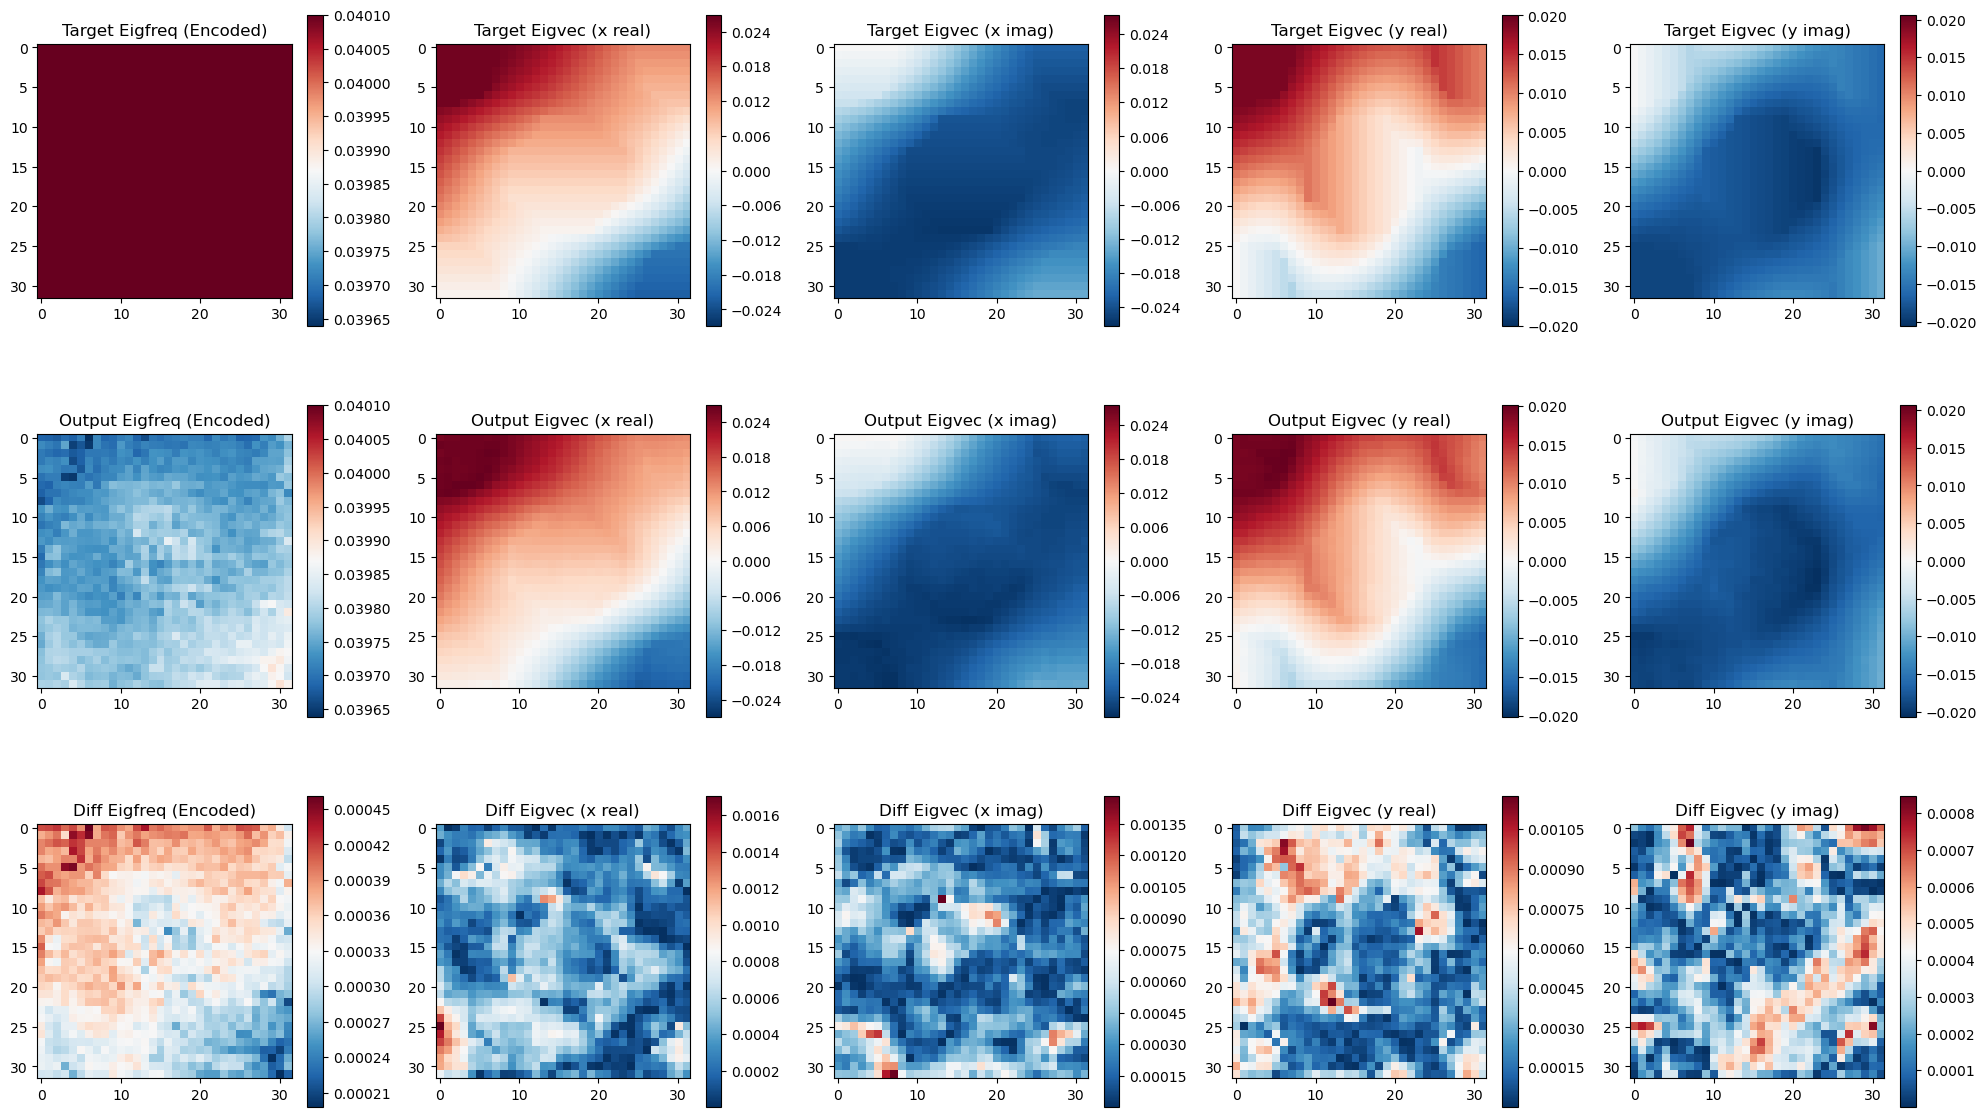

Sample 3: Input torch.Size([3, 32, 32]) torch.float16, Target torch.Size([5, 32, 32]) torch.float16
Input max: 1.0000, min: -0.8745
Output max: 0.1288, min: -0.0164
Target max: 0.1388, min: -0.0183
Target scale (max - min): 0.1571
Average absolute error per pixel (output vs target): 0.001134


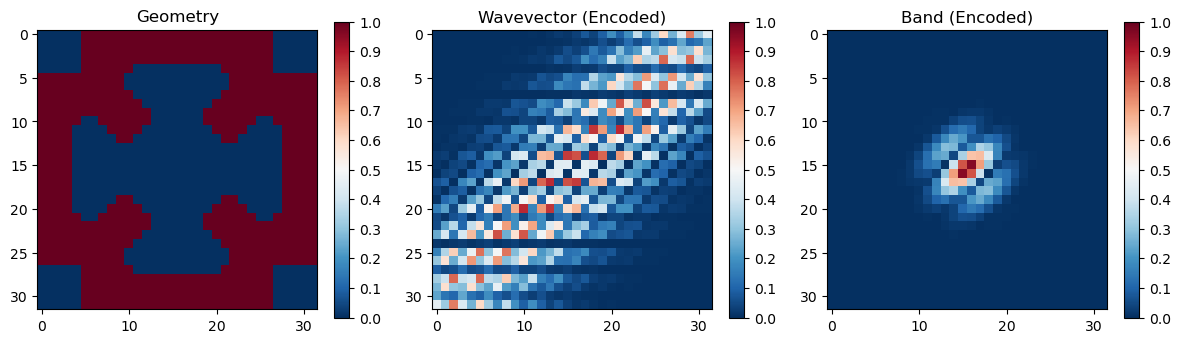

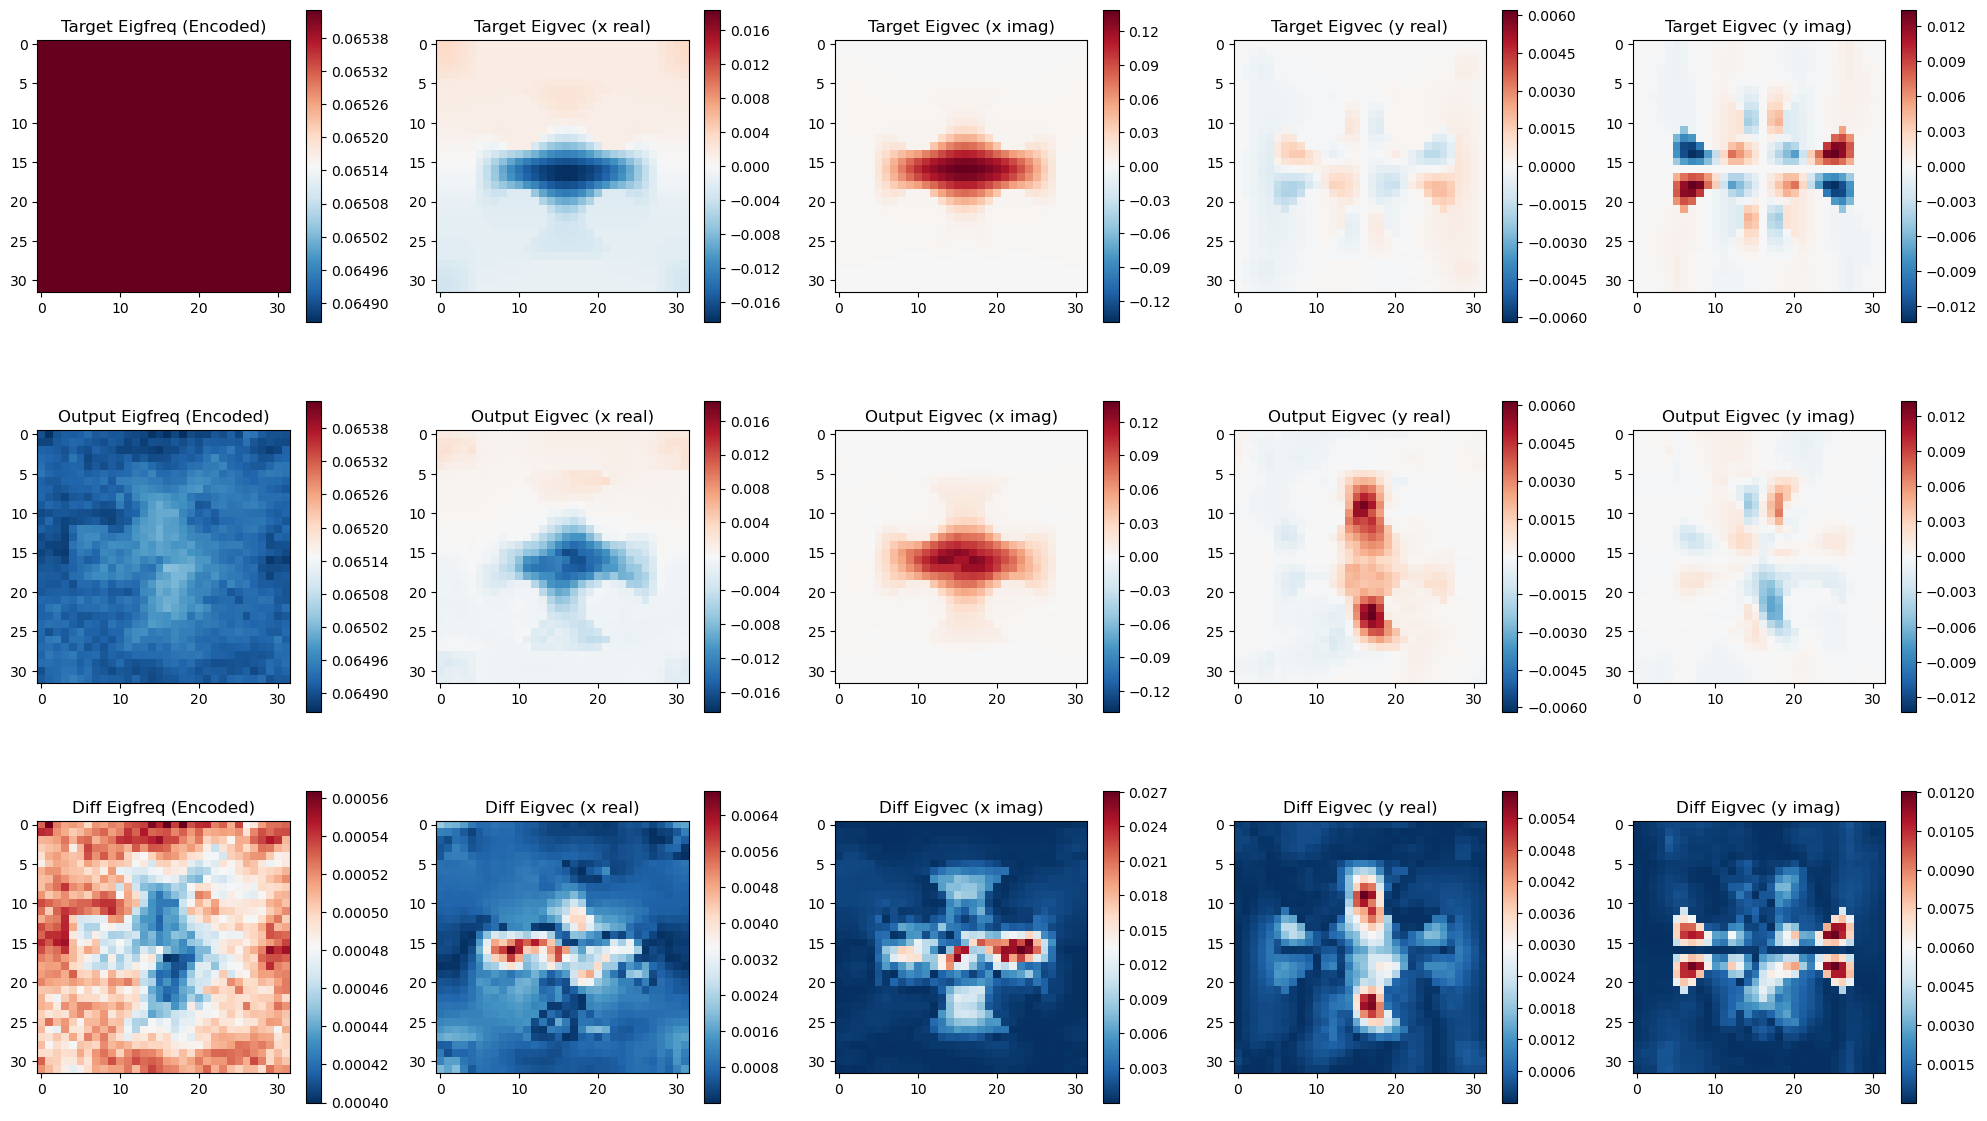

Sample 4: Input torch.Size([3, 32, 32]) torch.float16, Target torch.Size([5, 32, 32]) torch.float16
Input max: 1.0000, min: -0.7969
Output max: 0.0617, min: -0.0632
Target max: 0.0601, min: -0.0601
Target scale (max - min): 0.1202
Average absolute error per pixel (output vs target): 0.002187


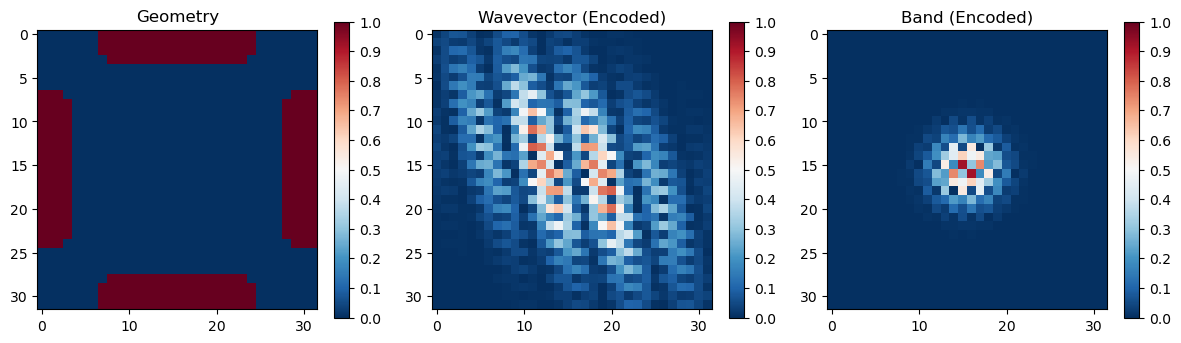

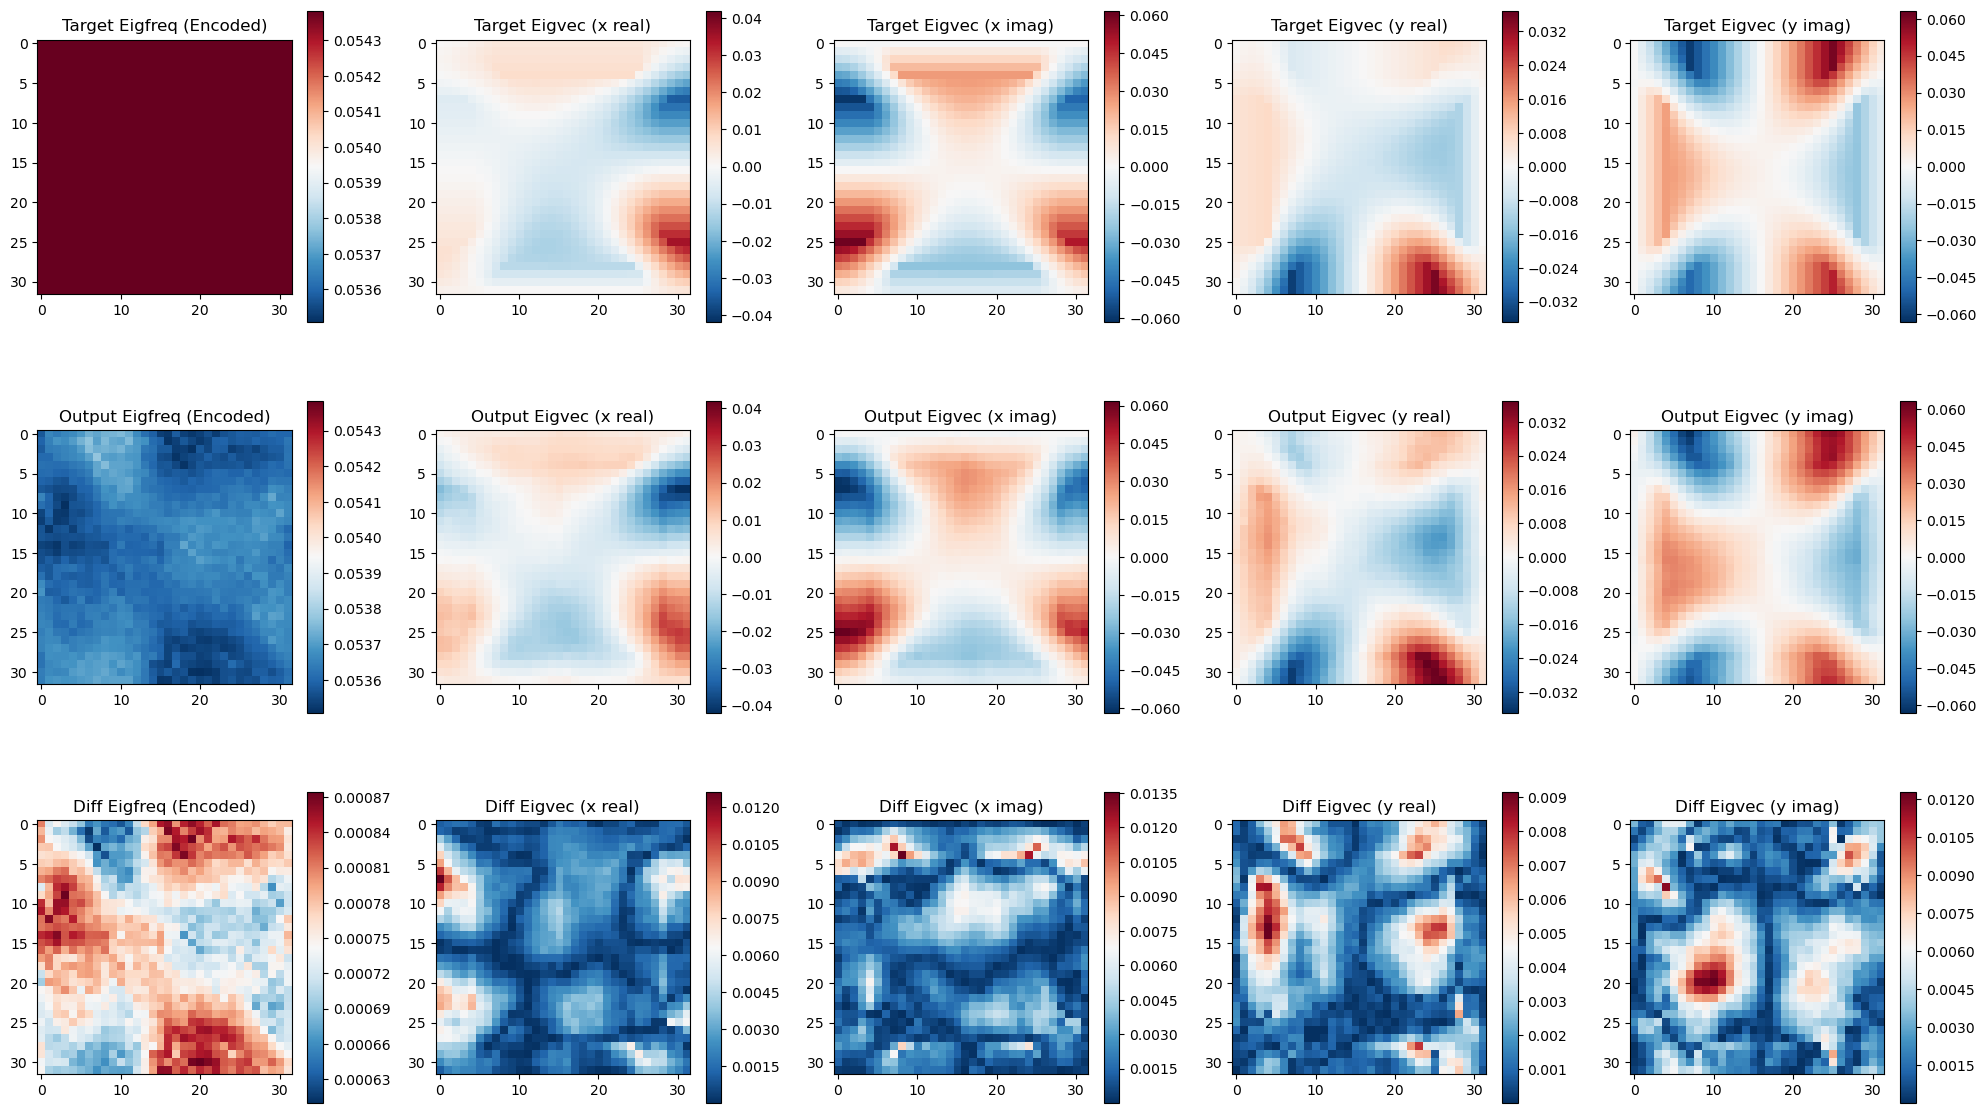

In [19]:
# Get a few random samples directly (no DataLoader needed)
num_samples = 5 # or however many you want
sample_seed = 50
sample_rng = torch.Generator().manual_seed(sample_seed)
random_indices = torch.randperm(len(reduced_indices), generator=sample_rng)[:num_samples]

# Preallocate lists for time efficiency
all_inputs = [None] * num_samples
all_predictions = [None] * num_samples
all_targets = [None] * num_samples

# Process each sample
for i, sample_idx in enumerate(random_indices):
    # Get the mapping indices
    geometry_idx, waveform_idx, band_idx = reduced_indices[int(sample_idx)]
    geometry_idx, waveform_idx, band_idx = int(geometry_idx), int(waveform_idx), int(band_idx)

    # Fetch the actual data
    geometry = geometries[geometry_idx]
    waveform = waveforms[waveform_idx]
    band_fft = band_ffts[band_idx]
    target = stack_target_channels(int(sample_idx), geometry_idx, waveform_idx, band_idx)
    
    # Combine inputs
    input_tensor = torch.stack([geometry, waveform, band_fft], dim=0)  # [3, 32, 32]
    
    # Check sizes and data types
    print(f"Sample {i}: Input {input_tensor.shape} {input_tensor.dtype}, Target {target.shape} {target.dtype}")
    
    # Convert to float32 if needed to match model expectations
    if input_tensor.dtype != torch.float32:
        input_tensor = input_tensor.float()
    if target.dtype != torch.float32:
        target = target.float()
    
    # Move to device
    input_tensor = input_tensor.to(device)
    target = target.to(device)
    
    # Get prediction
    with torch.no_grad():
        prediction = model(input_tensor.unsqueeze(0)).squeeze(0)  # Add batch dim, then remove
    
    # Print max and min of input, output, and target
    print(f"Input max: {input_tensor.max():.4f}, min: {input_tensor.min():.4f}")
    print(f"Output max: {prediction.max():.4f}, min: {prediction.min():.4f}")
    print(f"Target max: {target.max():.4f}, min: {target.min():.4f}")
    print(f"Target scale (max - min): {target.max() - target.min():.4f}")
    # Compute average absolute error per pixel between output and target
    avg_abs_error = torch.mean(torch.abs(prediction - target)).item()
    print(f"Average absolute error per pixel (output vs target): {avg_abs_error:.6f}")
    
    # Visualize the sample (move tensors to CPU first)
    NO_utilities.visualize_sample(
        input_tensor.cpu(), 
        prediction.cpu(), 
        target.cpu(),
        unified_colorbar=False,
        field_cmap="RdBu_r",
        diverge_center=0.0
    )
    
    # Store for plotting (keep as 3x32x32 for inputs, 5x32x32 for predictions and targets)
    all_inputs[i] = input_tensor.cpu()  # [3, 32, 32]
    all_predictions[i] = prediction.cpu()  # [5, 32, 32]
    all_targets[i] = target.cpu()  # [5, 32, 32]


Visualizing sample 0 (index 357904)


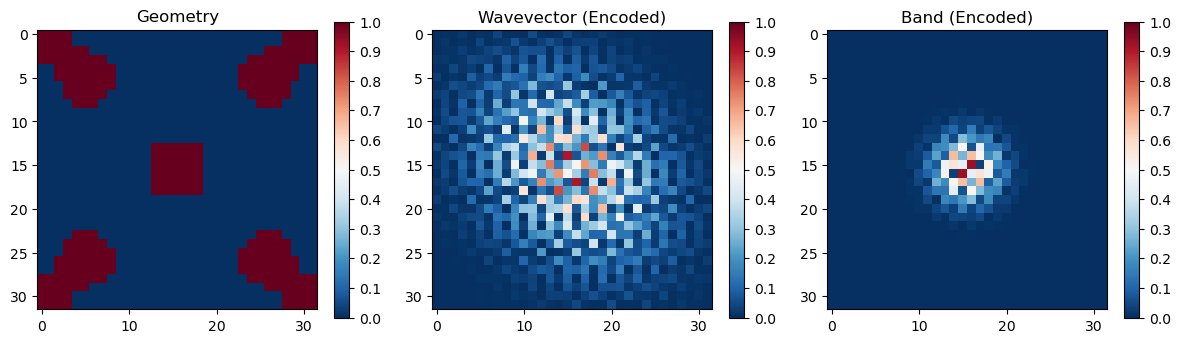

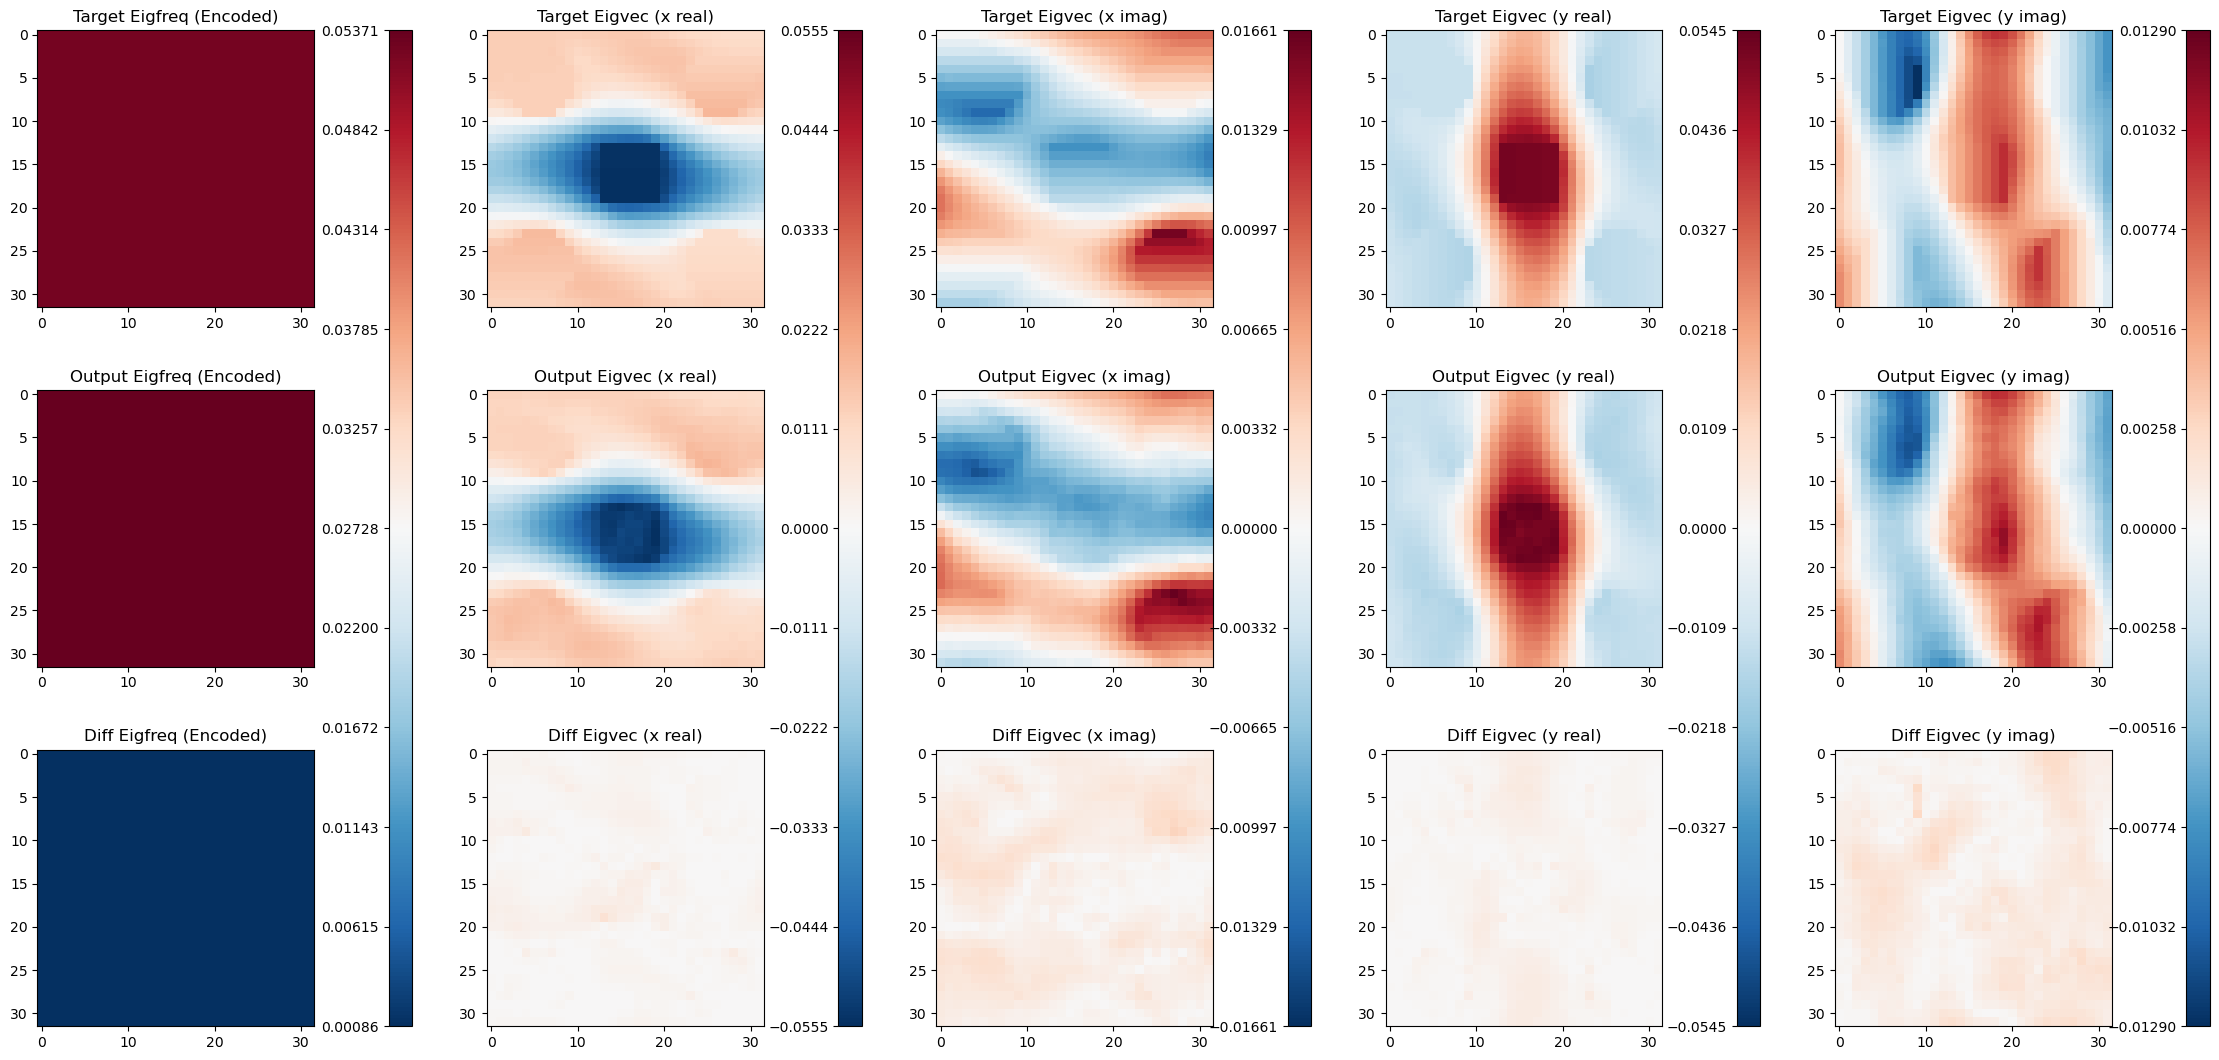

Visualizing sample 1 (index 222031)


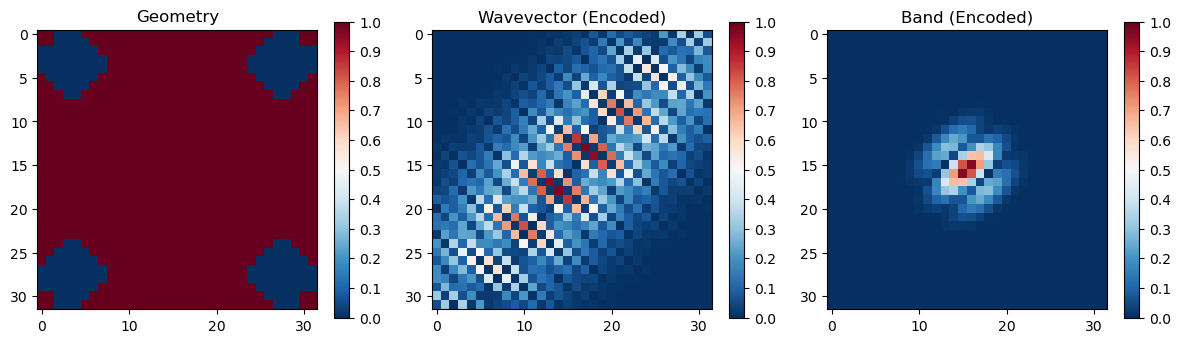

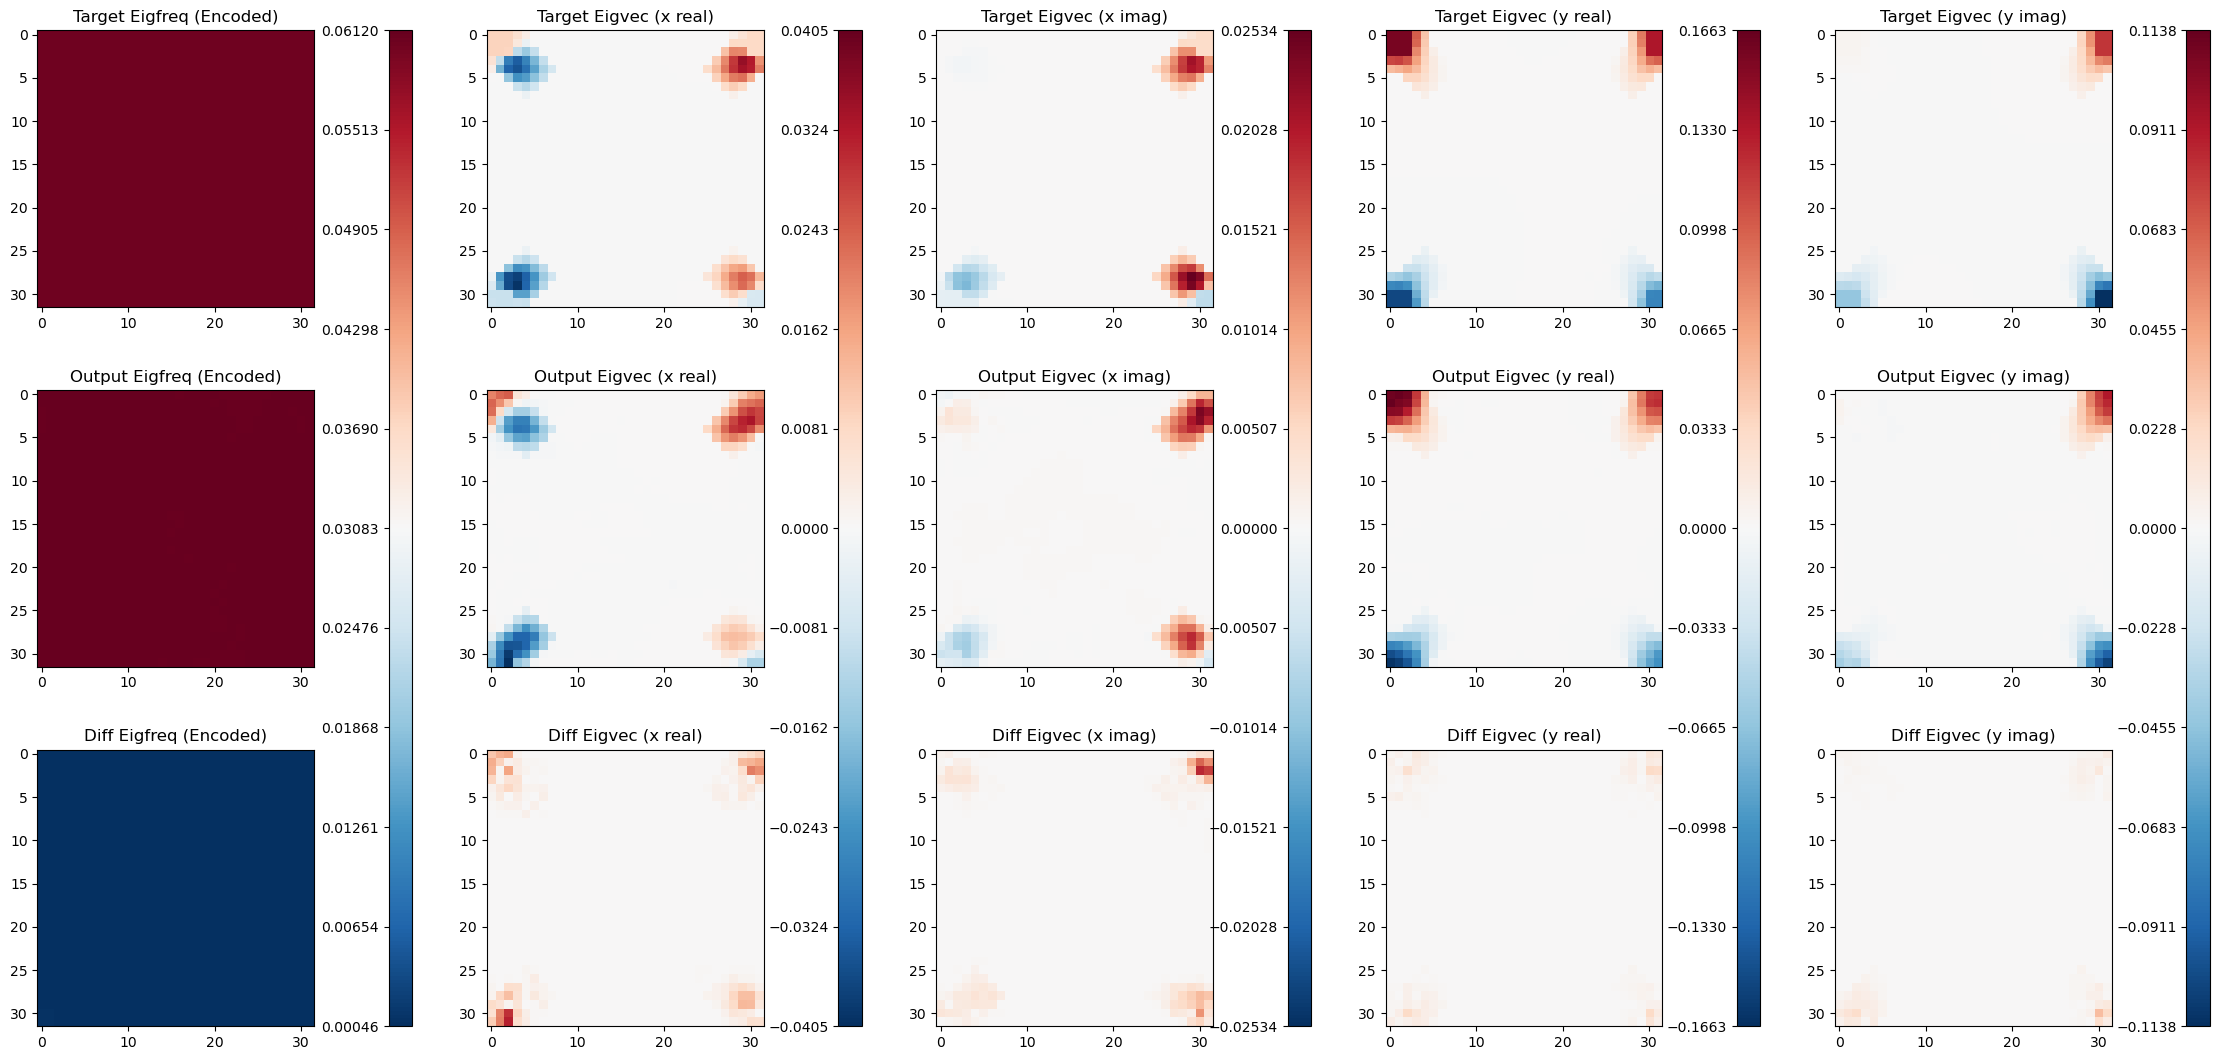

Visualizing sample 2 (index 324507)


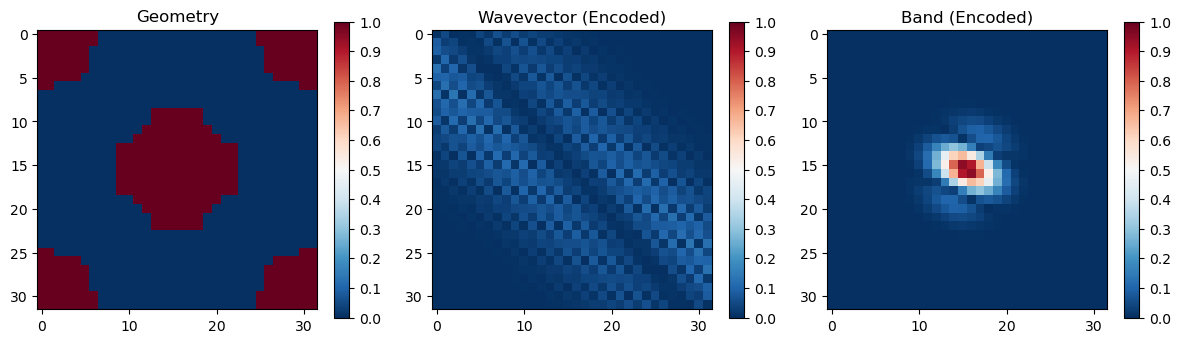

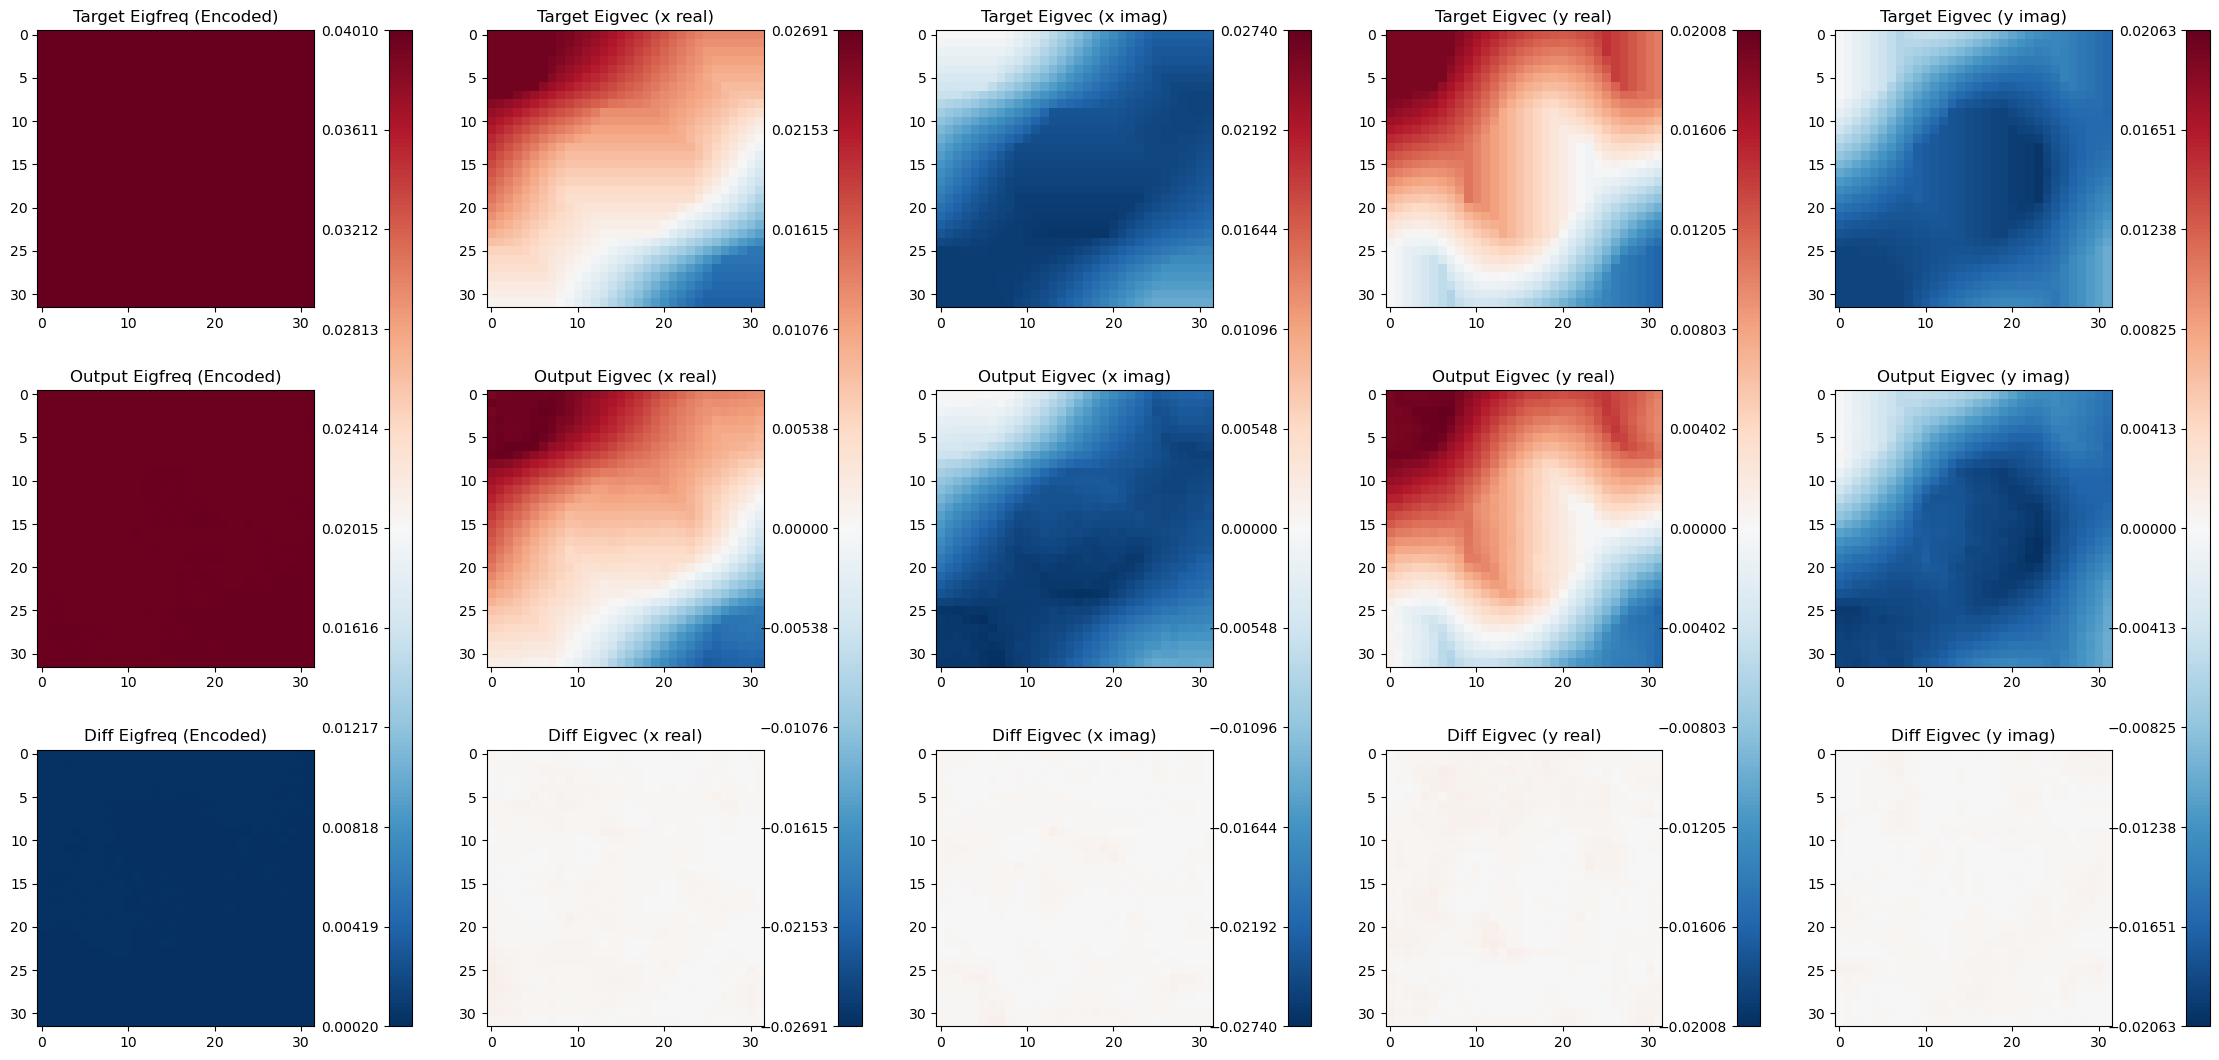

Visualizing sample 3 (index 37561)


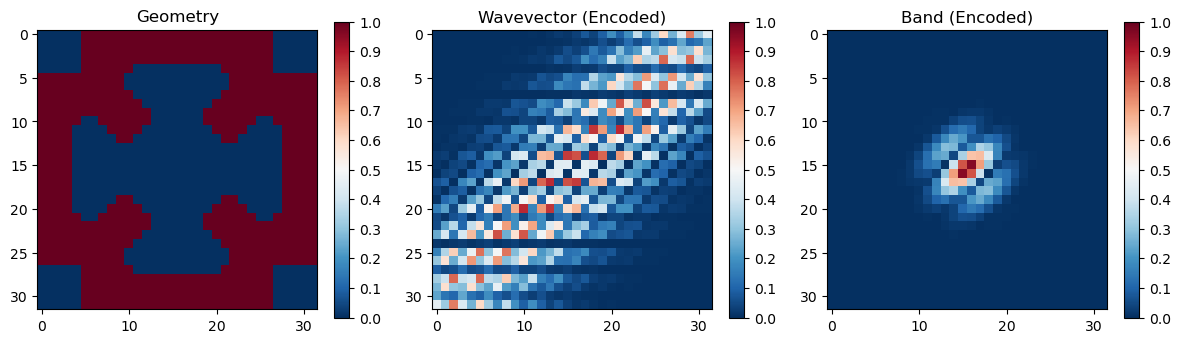

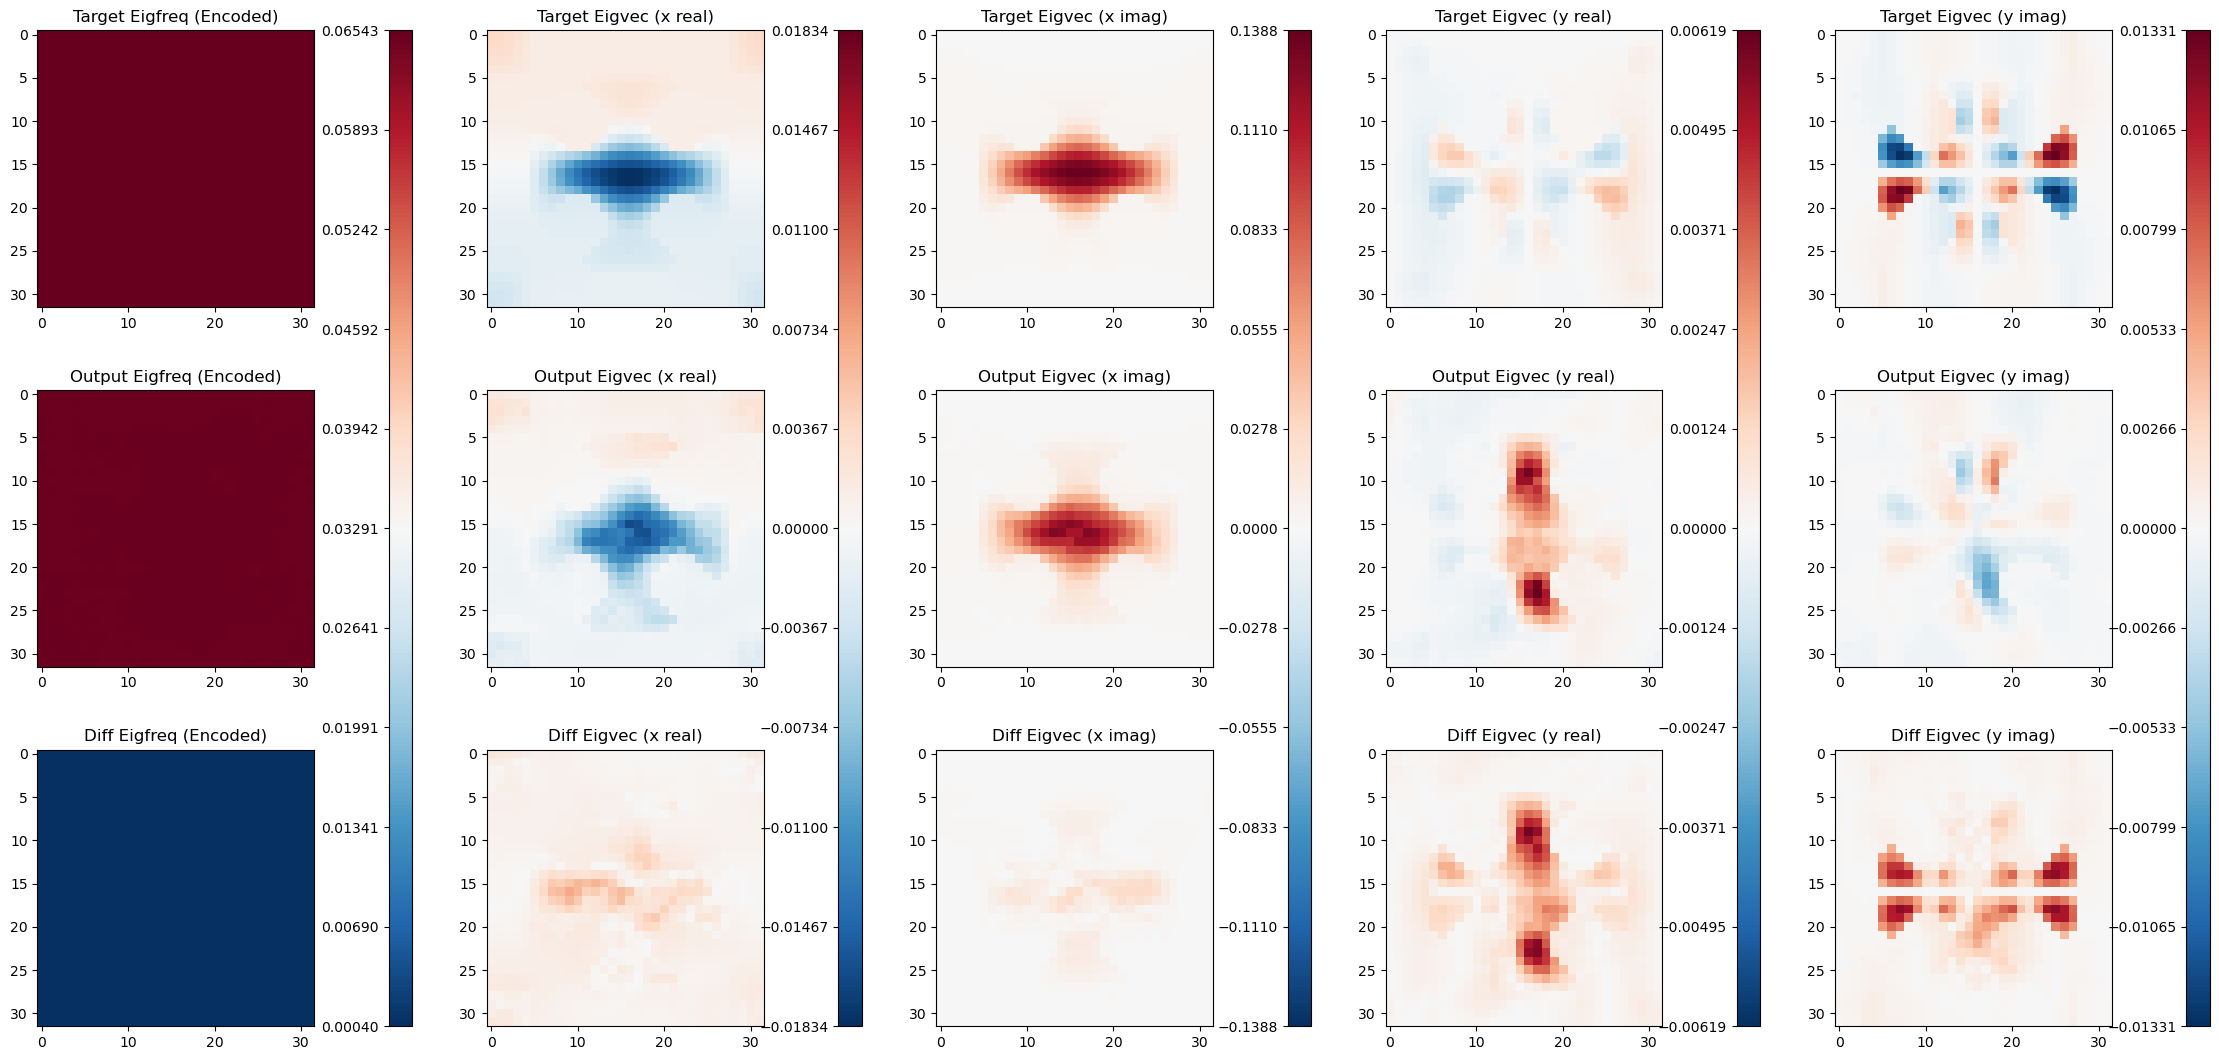

Visualizing sample 4 (index 193385)


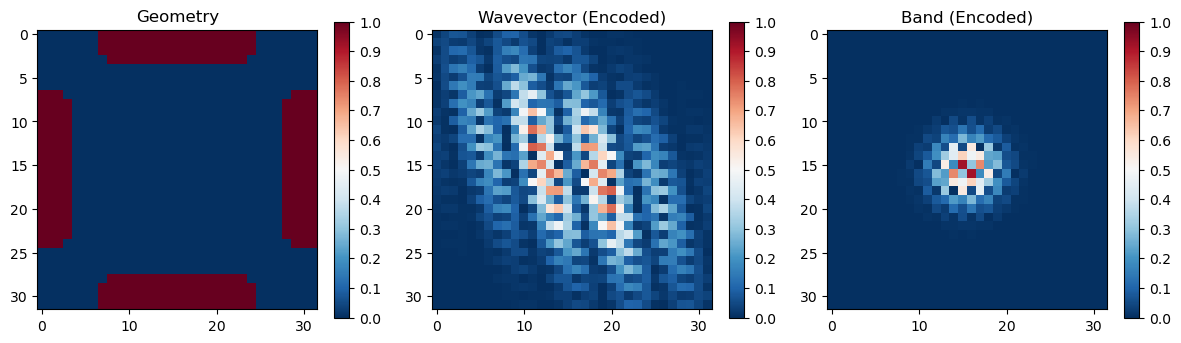

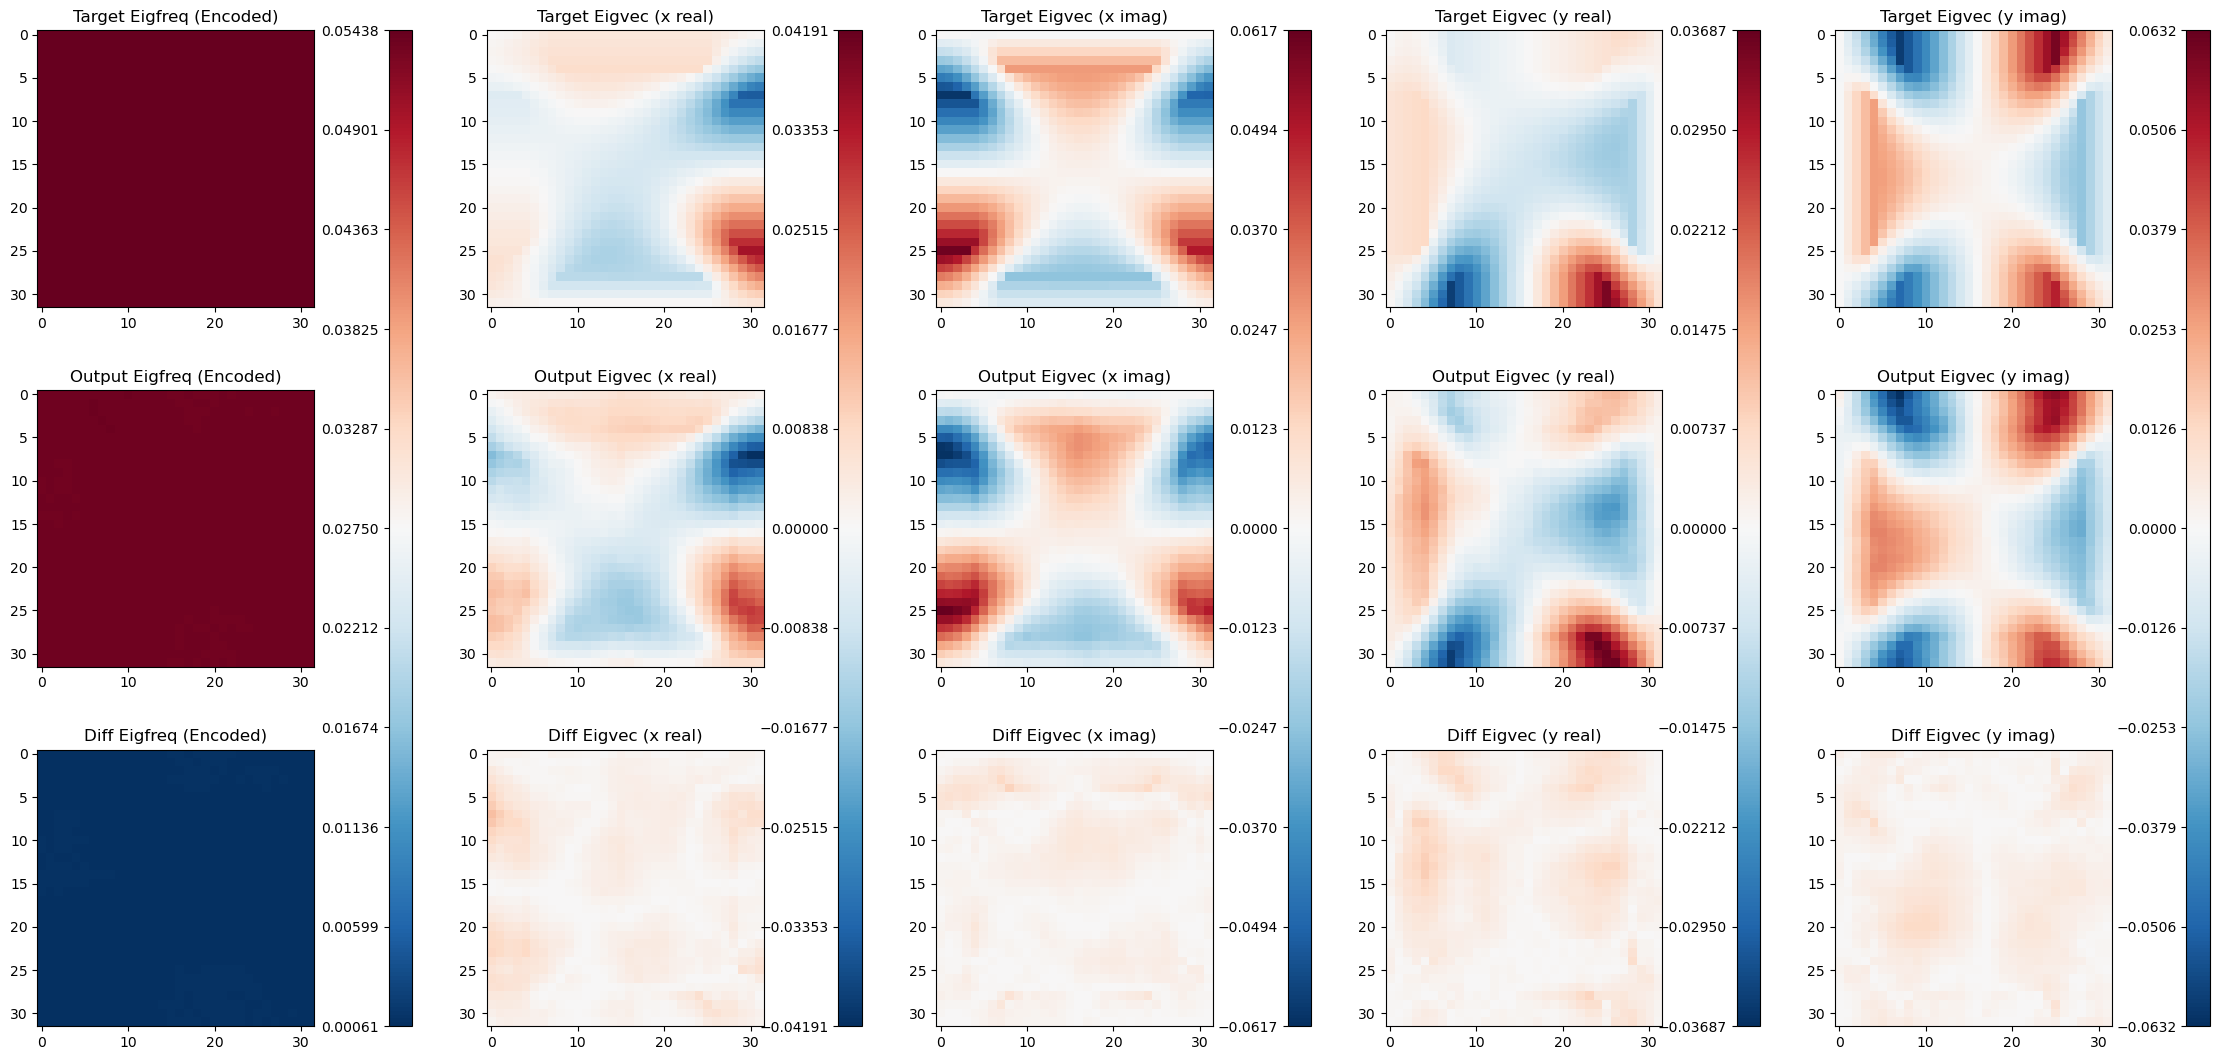

In [20]:
# Plots: NO_utilities.visualize_sample(..., unified_colorbar=True)
for i, sample_idx in enumerate(random_indices):
    print(f"Visualizing sample {i} (index {sample_idx})")

    input_sample = all_inputs[i]  # [3, 32, 32]
    output_sample = all_predictions[i]  # [C, 32, 32]
    target_sample = all_targets[i]  # [C, 32, 32]

    NO_utilities.visualize_sample(
        input_sample.cpu(),
        output_sample.cpu(),
        target_sample.cpu(),
        unified_colorbar=True,
        field_cmap="RdBu_r",
        diverge_center=0.0,
    )